# H1 - Selection des IPOs (2019-2021 vs 2022-2024)

## Hypothese testee
Les entreprises introduites en bourse sur **2022-2024** affichent :
- un **chiffre d'affaires median LTM** superieur,
- une **part d'entreprises rentables** (rentabilite nette LTM positive) superieure,
par rapport a la cohorte **2019-2021**.

## Protocole statistique
1. Statistiques descriptives par cohorte (mediane CA, part rentable)
2. Intervalles de confiance 95 %
   - **Bootstrap percentile** pour la mediane du CA LTM
   - **Wilson** pour la proportion d'entreprises rentables
3. Tests d'hypothese
   - **Mann-Whitney unilateral** pour le CA LTM (H1: 2022-2024 > 2019-2021)
   - **Z-test unilateral de proportion** pour la part rentable (H1: 2022-2024 > 2019-2021)

## Source de donnees
- `data/dataset_complet_filled.xlsx`

> Aucune simulation n'est utilisee dans ce notebook.

In [13]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.figsize": (10, 6), "figure.dpi": 120})

SEED = 42
rng = np.random.default_rng(SEED)
COLORS = {"2019-2021": "#2C7BB6", "2022-2024": "#D7191C"}

print("Imports OK")

Imports OK


In [14]:
DATA_PATH = "data/dataset_complet_filled.xlsx"
df = pd.read_excel(DATA_PATH)

required = ["year", "revenue_ltm", "profitable"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Colonnes manquantes: {missing}")

# Perimetre de l'etude H1
df = df[df["year"].between(2019, 2024)].copy()
df["cohort"] = np.where(df["year"].between(2019, 2021), "2019-2021", "2022-2024")

# Optionnel: conserver la logique de filtre d'emission >= 50M$ si la colonne existe
if "ipo_size_m" in df.columns:
    df = df[(df["ipo_size_m"].isna()) | (pd.to_numeric(df["ipo_size_m"], errors="coerce") >= 50)].copy()

# Nettoyage revenu
df["revenue_ltm"] = pd.to_numeric(df["revenue_ltm"], errors="coerce")

# Nettoyage profitable (supporte bool, numerique, texte)
prof_src = df["profitable"]
if pd.api.types.is_bool_dtype(prof_src):
    df["profitable_bin"] = prof_src.astype(float)
elif pd.api.types.is_numeric_dtype(prof_src):
    df["profitable_bin"] = (pd.to_numeric(prof_src, errors="coerce") > 0).astype(float)
else:
    txt = prof_src.astype(str).str.strip().str.lower()
    pos = {"1", "true", "yes", "y", "oui", "rentable", "profitable", "positive"}
    neg = {"0", "false", "no", "n", "non", "unprofitable", "negative"}
    df["profitable_bin"] = np.where(txt.isin(pos), 1.0, np.where(txt.isin(neg), 0.0, np.nan))

# Echantillons pour les tests
rev_19_21 = df.loc[(df["cohort"] == "2019-2021") & (df["revenue_ltm"].notna()), "revenue_ltm"].to_numpy()
rev_22_24 = df.loc[(df["cohort"] == "2022-2024") & (df["revenue_ltm"].notna()), "revenue_ltm"].to_numpy()
prof_19_21 = df.loc[(df["cohort"] == "2019-2021") & (df["profitable_bin"].notna()), "profitable_bin"].to_numpy()
prof_22_24 = df.loc[(df["cohort"] == "2022-2024") & (df["profitable_bin"].notna()), "profitable_bin"].to_numpy()

print(f"Fichier: {DATA_PATH}")
print(f"Lignes apres filtres: {len(df)}")
print("\nColonnes disponibles:")
print(df.columns.tolist())
print("\nEffectifs cohortes:")
print(df["cohort"].value_counts())
print(f"\nCA non manquant: 2019-2021={len(rev_19_21)} | 2022-2024={len(rev_22_24)}")
print(f"Rentabilite non manquante: 2019-2021={len(prof_19_21)} | 2022-2024={len(prof_22_24)}")

Fichier: data/dataset_complet_filled.xlsx
Lignes apres filtres: 321

Colonnes disponibles:
['ticker', 'year', 'ipo_date', 'open_px', 'close_px', 'underpricing', 'ret_30d', 'ret_12m', 'ipo_size_m', 'fed_rate', 'sic', 'sector', 'pe_backed', 'cohort', 'cohort_en', 'log_size', 'company_age', 'revenue_ltm', 'profitable', 'profitable_bin']

Effectifs cohortes:
cohort
2019-2021    237
2022-2024     84
Name: count, dtype: int64

CA non manquant: 2019-2021=208 | 2022-2024=83
Rentabilite non manquante: 2019-2021=237 | 2022-2024=84


In [15]:
def describe_cohort(label: str) -> dict:
    sub = df[df["cohort"] == label]
    rev = sub["revenue_ltm"].dropna()
    prof = sub["profitable_bin"].dropna()
    return {
        "Cohorte": label,
        "N IPOs": len(sub),
        "N CA non manquant": len(rev),
        "CA median LTM (M$)": np.median(rev) if len(rev) else np.nan,
        "CA Q1 (M$)": np.percentile(rev, 25) if len(rev) else np.nan,
        "CA Q3 (M$)": np.percentile(rev, 75) if len(rev) else np.nan,
        "N rentable non manquant": len(prof),
        "N rentables": int(np.nansum(prof)) if len(prof) else 0,
        "% rentables": 100 * np.nanmean(prof) if len(prof) else np.nan,
    }

desc = pd.DataFrame([
    describe_cohort("2019-2021"),
    describe_cohort("2022-2024")
])

display(desc.style.format({
    "CA median LTM (M$)": "{:.1f}",
    "CA Q1 (M$)": "{:.1f}",
    "CA Q3 (M$)": "{:.1f}",
    "% rentables": "{:.2f}%",
}))

,Cohorte,N IPOs,N CA non manquant,CA median LTM (M$),CA Q1 (M$),CA Q3 (M$),N rentable non manquant,N rentables,% rentables
0,2019-2021,237,208,163.2,48.3,588.7,237,56,23.63%
1,2022-2024,84,83,348.2,17.3,1618.6,84,43,51.19%


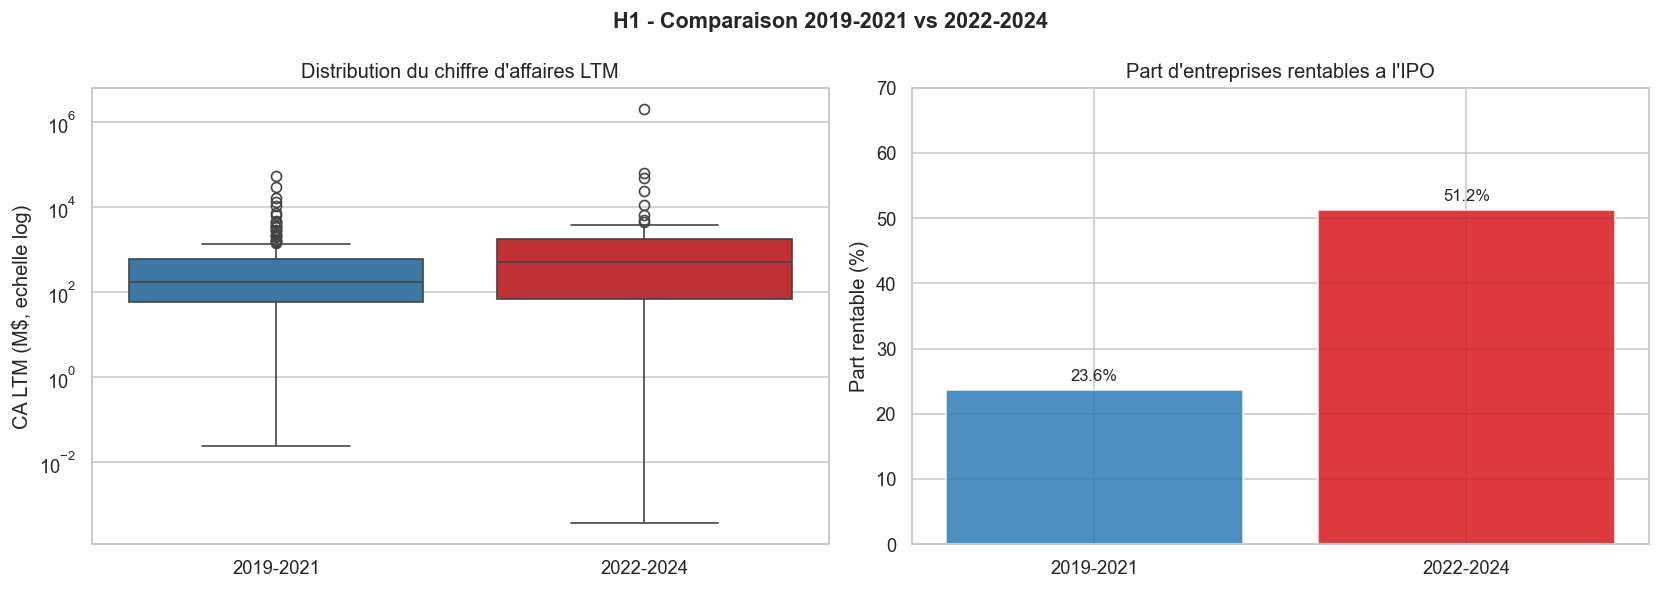

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1) Distribution du CA LTM (echelle log)
plot_df = df.dropna(subset=["revenue_ltm"]).copy()
plot_df = plot_df[plot_df["revenue_ltm"] > 0]

sns.boxplot(
    data=plot_df,
    x="cohort",
    y="revenue_ltm",
    order=["2019-2021", "2022-2024"],
    palette=[COLORS["2019-2021"], COLORS["2022-2024"]],
    ax=axes[0],
)
axes[0].set_yscale("log")
axes[0].set_xlabel("")
axes[0].set_ylabel("CA LTM (M$, echelle log)")
axes[0].set_title("Distribution du chiffre d'affaires LTM")

# 2) Part d'entreprises rentables
prop = (
    df.dropna(subset=["profitable_bin"])
      .groupby("cohort")["profitable_bin"]
      .mean()
      .reindex(["2019-2021", "2022-2024"]) * 100
)

bars = axes[1].bar(
    prop.index,
    prop.values,
    color=[COLORS["2019-2021"], COLORS["2022-2024"]],
    alpha=0.85,
)
for bar, val in zip(bars, prop.values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{val:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
    )
axes[1].set_ylim(0, max(70, float(np.nanmax(prop.values) + 10)))
axes[1].set_xlabel("")
axes[1].set_ylabel("Part rentable (%)")
axes[1].set_title("Part d'entreprises rentables a l'IPO")

fig.suptitle("H1 - Comparaison 2019-2021 vs 2022-2024", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [17]:
def median_ci_bootstrap(x, n_boot=10_000, alpha=0.05, seed=SEED):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    if len(x) == 0:
        return np.nan, np.nan, np.nan
    gen = np.random.default_rng(seed)
    idx = gen.integers(0, len(x), size=(n_boot, len(x)))
    med_boot = np.median(x[idx], axis=1)
    lo = np.quantile(med_boot, alpha / 2)
    hi = np.quantile(med_boot, 1 - alpha / 2)
    return np.median(x), lo, hi

med_19, med_19_lo, med_19_hi = median_ci_bootstrap(rev_19_21, seed=SEED)
med_22, med_22_lo, med_22_hi = median_ci_bootstrap(rev_22_24, seed=SEED + 1)

k1, n1 = int(np.nansum(prof_19_21)), len(prof_19_21)
k2, n2 = int(np.nansum(prof_22_24)), len(prof_22_24)

p1 = k1 / n1 if n1 else np.nan
p2 = k2 / n2 if n2 else np.nan

p1_lo, p1_hi = proportion_confint(k1, n1, alpha=0.05, method="wilson") if n1 else (np.nan, np.nan)
p2_lo, p2_hi = proportion_confint(k2, n2, alpha=0.05, method="wilson") if n2 else (np.nan, np.nan)

print("=== IC 95% - Mediane CA LTM (bootstrap) ===")
print(f"2019-2021 : {med_19:,.1f} M$ | [{med_19_lo:,.1f} ; {med_19_hi:,.1f}]".replace(",", " "))
print(f"2022-2024 : {med_22:,.1f} M$ | [{med_22_lo:,.1f} ; {med_22_hi:,.1f}]".replace(",", " "))

print("\n=== IC 95% - Part rentable (Wilson) ===")
print(f"2019-2021 : {p1:.2%} | [{p1_lo:.2%} ; {p1_hi:.2%}]")
print(f"2022-2024 : {p2:.2%} | [{p2_lo:.2%} ; {p2_hi:.2%}]")

=== IC 95% - Mediane CA LTM (bootstrap) ===
2019-2021 : 163.2 M$ | [140.5 ; 225.3]
2022-2024 : 348.2 M$ | [171.2 ; 722.4]

=== IC 95% - Part rentable (Wilson) ===
2019-2021 : 23.63% | [18.67% ; 29.43%]
2022-2024 : 51.19% | [40.69% ; 61.59%]


In [18]:
alpha = 0.05

# Test de Mann-Whitney unilateral pour le CA
if len(rev_19_21) > 0 and len(rev_22_24) > 0:
    u_stat, p_mw = stats.mannwhitneyu(rev_22_24, rev_19_21, alternative="greater")
else:
    u_stat, p_mw = np.nan, np.nan

# Test unilateral de proportion (part rentable)
if n1 > 0 and n2 > 0:
    z_stat, p_z = proportions_ztest([k2, k1], [n2, n1], alternative="larger")
else:
    z_stat, p_z = np.nan, np.nan

results = pd.DataFrame({
    "Test": [
        "Mann-Whitney U (CA LTM): H1 2022-2024 > 2019-2021",
        "Z-test proportion rentable: H1 2022-2024 > 2019-2021",
    ],
    "Statistique": [u_stat, z_stat],
    "p-value": [p_mw, p_z],
    "Significatif a 5%": [bool(np.isfinite(p_mw) and p_mw < alpha), bool(np.isfinite(p_z) and p_z < alpha)],
})

display(results.style.format({"Statistique": "{:.4f}", "p-value": "{:.4f}"}))

print("\n=== Decision H1 ===")
print("H1a (CA median superieur en 2022-2024):", "CONFIRMEE" if np.isfinite(p_mw) and p_mw < alpha else "NON CONFIRMEE")
print("H1b (part rentable superieure en 2022-2024):", "CONFIRMEE" if np.isfinite(p_z) and p_z < alpha else "NON CONFIRMEE")


,Test,Statistique,p-value,Significatif a 5%
0,Mann-Whitney U (CA LTM): H1 2022-2024 > 2019-2021,9699.0000,0.0499,True
1,Z-test proportion rentable: H1 2022-2024 > 2019-2021,4.6998,0.0000,True



=== Decision H1 ===
H1a (CA median superieur en 2022-2024): CONFIRMEE
H1b (part rentable superieure en 2022-2024): CONFIRMEE


In [19]:
summary_final = pd.DataFrame({
    "Indicateur": [
        "CA median LTM (M$)",
        "IC95 mediane CA (M$)",
        "Part rentable (%)",
        "IC95 part rentable",
        "p-value Mann-Whitney (CA)",
        "p-value Z-test (part rentable)",
    ],
    "2019-2021": [
        f"{med_19:,.1f}".replace(",", " "),
        f"[{med_19_lo:,.1f} ; {med_19_hi:,.1f}]".replace(",", " "),
        f"{100*p1:.2f}%",
        f"[{100*p1_lo:.2f}% ; {100*p1_hi:.2f}%]",
        "",
        "",
    ],
    "2022-2024": [
        f"{med_22:,.1f}".replace(",", " "),
        f"[{med_22_lo:,.1f} ; {med_22_hi:,.1f}]".replace(",", " "),
        f"{100*p2:.2f}%",
        f"[{100*p2_lo:.2f}% ; {100*p2_hi:.2f}%]",
        "",
        "",
    ],
    "Valeur test": [
        "",
        "",
        "",
        "",
        f"{p_mw:.4f}" if np.isfinite(p_mw) else "NA",
        f"{p_z:.4f}" if np.isfinite(p_z) else "NA",
    ],
})

display(summary_final)

print("\nLecture recommandee:")
print("- Si p-value Mann-Whitney < 0,05: CA LTM statistiquement plus eleve en 2022-2024.")
print("- Si p-value Z-test < 0,05: part d'entreprises rentables statistiquement plus elevee en 2022-2024.")
print("- Conclusion H1 = confirmee seulement si les deux composantes sont significatives.")

,Indicateur,2019-2021,2022-2024,Valeur test
0,CA median LTM (M$),163.2,348.2,
1,IC95 mediane CA (M$),[140.5 ; 225.3],[171.2 ; 722.4],
2,Part rentable (%),23.63%,51.19%,
3,IC95 part rentable,[18.67% ; 29.43%],[40.69% ; 61.59%],
4,p-value Mann-Whitney (CA),,,0.0499
5,p-value Z-test (part rentable),,,0.0000



Lecture recommandee:
- Si p-value Mann-Whitney < 0,05: CA LTM statistiquement plus eleve en 2022-2024.
- Si p-value Z-test < 0,05: part d'entreprises rentables statistiquement plus elevee en 2022-2024.
- Conclusion H1 = confirmee seulement si les deux composantes sont significatives.
